In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import joblib

%matplotlib inline
sns.set_style('whitegrid')
print("imported")

imported


In [3]:
df = pd.read_csv("../data/delhi_ncr_aqi_dataset.csv")
df = df.drop(columns=['datetime', 'date', 'station', 'latitude', 'longitude'])

day_map = {'Monday':0,'Tuesday':1,'Wednesday':2,'Thursday':3,
           'Friday':4,'Saturday':5,'Sunday':6}
season_map = {'monsoon':0,'summer':1,'post_monsoon':2,'winter':3}

df['day_of_week'] = df['day_of_week'].map(day_map)
df['season']      = df['season'].map(season_map)
df['city']        = LabelEncoder().fit_transform(df['city'])

weather_features = ['year', 'month', 'day', 'hour',
                    'day_of_week', 'is_weekend', 'season', 'city',
                    'temperature', 'humidity', 'wind_speed', 'visibility']

X = df[weather_features]
y = df['aqi']

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

model = joblib.load("../models/best_model_xgboost.pkl")

preds = model.predict(X_te)

print("Data ready!")
print(f"Test rows: {X_te.shape[0]:,}")

Data ready!
Test rows: 40,333


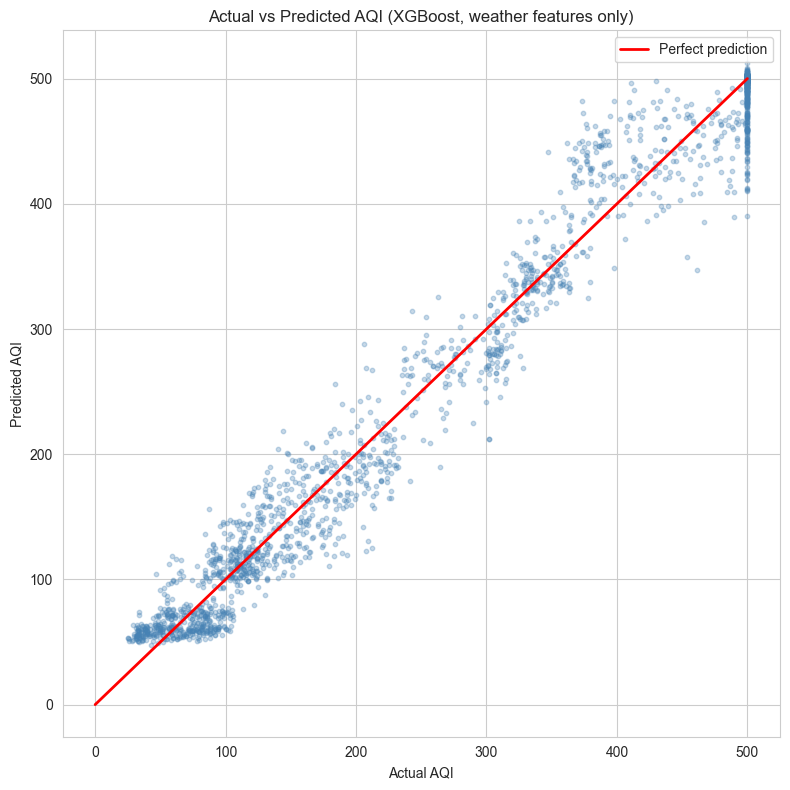

In [4]:
plt.figure(figsize=(8, 8))

sample_idx = np.random.choice(len(y_te), 2000, replace=False)
actual = y_te.values[sample_idx]
predicted = preds[sample_idx]

plt.scatter(actual, predicted, alpha=0.3, color='steelblue', s=10)

plt.plot([0, 500], [0, 500], color='red', linewidth=2, label='Perfect prediction')

plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI (XGBoost, weather features only)")
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/actual_vs_predicted.png')
plt.show()

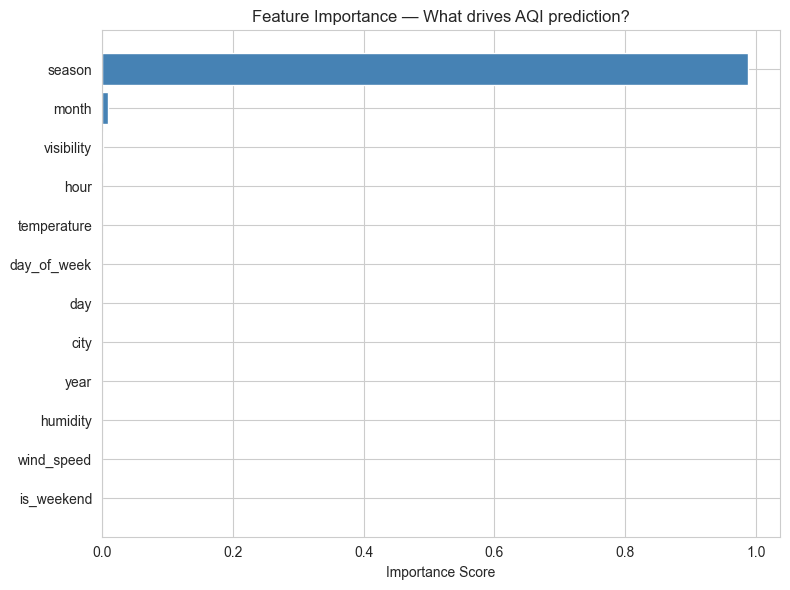

In [5]:
importance = model.feature_importances_
features   = weather_features

# Sort by importance
sorted_idx = np.argsort(importance)

plt.figure(figsize=(8, 6))
plt.barh([features[i] for i in sorted_idx],
         [importance[i] for i in sorted_idx],
         color='steelblue', edgecolor='white')

plt.xlabel("Importance Score")
plt.title("Feature Importance — What drives AQI prediction?")
plt.tight_layout()
plt.savefig('../outputs/feature_importance.png')
plt.show()

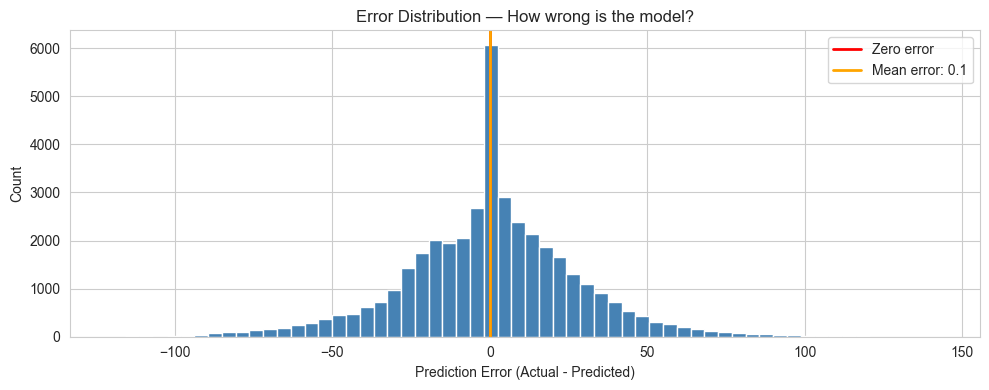

Mean error:   0.10
Most errors fall between: -15 and 15 AQI points


In [6]:
errors = y_te.values - preds

plt.figure(figsize=(10, 4))
plt.hist(errors, bins=60, color='steelblue', edgecolor='white')
plt.axvline(0, color='red', linewidth=2, label='Zero error')
plt.axvline(errors.mean(), color='orange', linewidth=2, 
            label=f'Mean error: {errors.mean():.1f}')
plt.xlabel("Prediction Error (Actual - Predicted)")
plt.ylabel("Count")
plt.title("Error Distribution — How wrong is the model?")
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/error_distribution.png')
plt.show()

print(f"Mean error:   {errors.mean():.2f}")
print(f"Most errors fall between: {np.percentile(errors,25):.0f} and {np.percentile(errors,75):.0f} AQI points")